In [ ]:
import pandas as pd
import ast
from datasets import Dataset
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, multilabel_confusion_matrix
from sklearn.model_selection import train_test_split
import numpy as np
import torch
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification, 
    TrainingArguments, 
    Trainer,
    EarlyStoppingCallback
)
import matplotlib.pyplot as plt
import json
import warnings
warnings.filterwarnings("ignore")
import seaborn as sns

/home/nexpg/anaconda3/envs/my314/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df = pd.read_csv('rnc_dataset_markup_with_split.csv')
df['targetDetectedMcIds'] = df['targetDetectedMcIds'].apply(ast.literal_eval)
df['targetSplitMcIds'] = df['targetSplitMcIds'].apply(ast.literal_eval)

# 1. Проверка уникальных категорий и их частоты
all_labels = sorted(set([label for labels in df['targetDetectedMcIds'] for label in labels]))
print(f"Всего категорий: {len(all_labels)}")

# 2. Разделение данных по столбцу split
train_df = df[df['split'] == 'train']

print(train_df)

Всего категорий: 10
       itemId  sourceMcId                    sourceMcTitle  \
0     1000001         101  Ремонт квартир и домов под ключ   
2     1000003         101  Ремонт квартир и домов под ключ   
4     1000005         101  Ремонт квартир и домов под ключ   
5     1000006         101  Ремонт квартир и домов под ключ   
6     1000007         101  Ремонт квартир и домов под ключ   
...       ...         ...                              ...   
2474  1002495         101  Ремонт квартир и домов под ключ   
2475  1002496         101  Ремонт квартир и домов под ключ   
2477  1002498         101  Ремонт квартир и домов под ключ   
2478  1002499         101  Ремонт квартир и домов под ключ   
2479  1002500         101  Ремонт квартир и домов под ключ   

                                            description  \
0     Всё виды строительных работ\r\nКачественно, в ...   
2               ремонт квартир, ванной комнате , балкон   
4     Ремонт квартир любой сложности. Квартиры под к...   

In [ ]:
# ====================== 1. Разделяем df_train на train и val (с stratify) ======================

train_df, val_df = train_test_split(
    df_train,
    test_size=0.20,                    # 20% на валидацию
    random_state=42,
    shuffle=True,
    stratify=df_train['shouldSplit']   # ← стратификация по shouldSplit
)

print(f"Размер обучающей выборки: {len(train_df)}")
print(f"Размер валидационной выборки: {len(val_df)}")

# ====================== 1. Подготовка меток ======================
all_mc_ids = sorted(set([mc for mcs in df['targetDetectedMcIds'] for mc in mcs]))
id2idx = {mc_id: i for i, mc_id in enumerate(all_mc_ids)}
print(f"Всего микрокатегорий: {len(all_mc_ids)}")

def create_multi_label_matrix(df: pd.DataFrame, target_column: str):
    matrix = np.zeros((len(df), len(all_mc_ids)), dtype=np.float32)
    for idx, mc_list in enumerate(df[target_column]):
        for mc in mc_list:
            if mc in id2idx:
                matrix[idx, id2idx[mc]] = 1.0
    return matrix

train_detected = create_multi_label_matrix(train_df, 'targetDetectedMcIds')
train_split    = create_multi_label_matrix(train_df, 'targetSplitMcIds')
val_detected   = create_multi_label_matrix(val_df,   'targetDetectedMcIds')
val_split      = create_multi_label_matrix(val_df,   'targetSplitMcIds')

# ====================== 2. Подготовка текста ======================
def prepare_text(row):
    return f"Исходная категория: {row['sourceMcTitle']} (ID {row['sourceMcId']}). {row['description']}"

train_df['text'] = train_df.apply(prepare_text, axis=1)
val_df['text']   = val_df.apply(prepare_text, axis=1)

# ====================== 3. Токенизация ======================
tokenizer = AutoTokenizer.from_pretrained("deepvk/USER2-base")   # ты выбрал этот

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=512)

# Detected
train_dataset_d = Dataset.from_pandas(train_df[['text']]).map(tokenize_function, batched=True)
train_dataset_d = train_dataset_d.add_column("labels", train_detected.tolist())

val_dataset_d = Dataset.from_pandas(val_df[['text']]).map(tokenize_function, batched=True)
val_dataset_d = val_dataset_d.add_column("labels", val_detected.tolist())

# Split
train_dataset_s = Dataset.from_pandas(train_df[['text']]).map(tokenize_function, batched=True)
train_dataset_s = train_dataset_s.add_column("labels", train_split.tolist())

val_dataset_s = Dataset.from_pandas(val_df[['text']]).map(tokenize_function, batched=True)
val_dataset_s = val_dataset_s.add_column("labels", val_split.tolist())

# ====================== 4. Тренер с улучшенными параметрами ======================
def get_trainer(train_ds, val_ds, output_dir):
    model = AutoModelForSequenceClassification.from_pretrained(
        "deepvk/USER2-base",                    # лучше взять ту же базу, что и токенизатор
        num_labels=len(all_mc_ids),
        problem_type="multi_label_classification"
    )

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = (torch.sigmoid(torch.tensor(logits)) > 0.5).numpy().astype(int)
        
        # === РУЧНОЙ РАСЧЁТ МЕТРИК (решает проблему evaluate.load) ===
        labels_flat = labels.flatten()
        preds_flat = preds.flatten()
        
        tp = np.sum((preds_flat == 1) & (labels_flat == 1))
        fp = np.sum((preds_flat == 1) & (labels_flat == 0))
        fn = np.sum((preds_flat == 0) & (labels_flat == 1))
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        
        # Диагностика во время обучения (будет выводиться каждый epoch)
        print(f"  [VAL DEBUG] TP={tp} FP={fp} FN={fn} | true={int(np.sum(labels_flat))} pred={int(np.sum(preds_flat))}")
        
        return {
            "micro_f1": float(f1),
            "micro_precision": float(precision),
            "micro_recall": float(recall),
        }

    training_args = TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=10,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=16,
        gradient_accumulation_steps=2,
        learning_rate=3e-5,
        weight_decay=0.01,
        warmup_steps=100,
        lr_scheduler_type="cosine",
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="micro_f1",
        greater_is_better=True,
        fp16=True,
        logging_strategy="steps",
        logging_steps=10,
        save_total_limit=2,
        dataloader_num_workers=4,
        report_to="none",
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2, early_stopping_threshold=0.001)]
    )
    return trainer

# ====================== 5. Обучение ======================
print("=== Обучаем Detected модель ===")
trainer_detected = get_trainer(train_dataset_d, val_dataset_d, "./results_detected")
trainer_detected.train()

print("=== Обучаем Split модель ===")
trainer_split = get_trainer(train_dataset_s, val_dataset_s, "./results_split")
trainer_split.train()

# ====================== 6. Сохранение моделей ======================
trainer_detected.save_model("./final_detected_model")
trainer_split.save_model("./final_split_model")

print("Модели сохранены в:")
print(" - ./final_detected_model")
print(" - ./final_split_model")

Всего микрокатегорий: 11


Map: 100%|██████████| 447/447 [00:00<00:00, 5536.90 examples/s]


=== Обучаем Detected модель ===


Loading weights: 100%|██████████| 134/134 [00:00<00:00, 14248.62it/s]
ModernBertForSequenceClassification LOAD REPORT from: deepvk/USER2-base
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
head.dense.weight | MISSING | 
head.norm.weight  | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Micro F1,Micro Precision,Micro Recall
1,0.388600,0.175921,0.865557,0.902135,0.831829
2,0.156464,0.120842,0.917808,0.959714,0.879409
3,0.172325,0.105304,0.920648,0.959111,0.885152
4,0.060687,0.128200,0.916980,0.932937,0.901559
5,0.036481,0.131896,0.923722,0.944302,0.904020
6,0.021378,0.148776,0.923077,0.952049,0.895816
7,0.008206,0.145092,0.929506,0.957391,0.903199
8,0.005007,0.147966,0.929267,0.960595,0.899918
9,0.004339,0.148709,0.930055,0.962281,0.899918


...

  [VAL DEBUG] TP=405 FP=16 FN=18 | true=423 pred=421


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.64s/it]


  [VAL DEBUG] TP=405 FP=15 FN=18 | true=423 pred=420


Writing model shards: 100%|██████████| 1/1 [00:06<00:00,  6.10s/it]

Модели сохранены в:
 - ./final_detected_model
 - ./final_split_model


График для Detected модели:


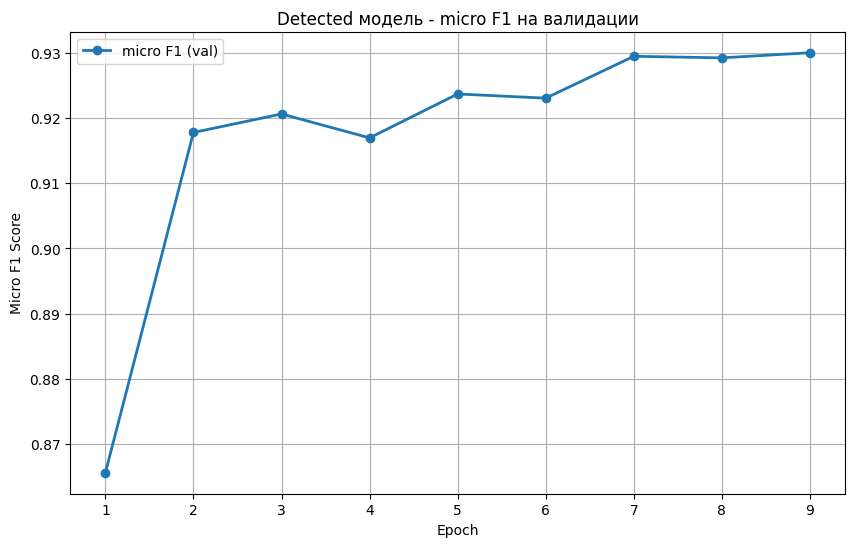

График для Split модели:


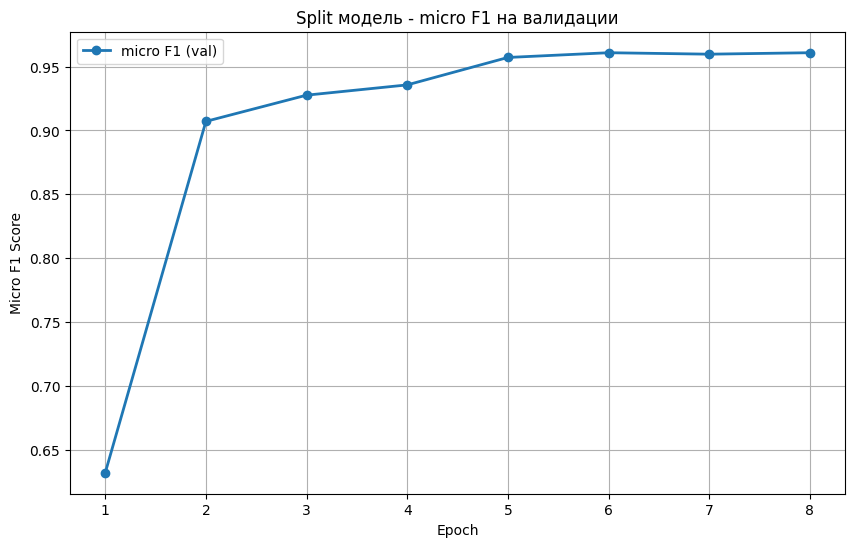

In [7]:
def plot_metrics(trainer, title):
    history = trainer.state.log_history
    epochs = []
    f1_scores = []
    
    for x in history:
        if 'eval_micro_f1' in x:
            epochs.append(x.get('epoch'))
            f1_scores.append(x.get('eval_micro_f1'))
    
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, f1_scores, marker='o', linewidth=2, label='micro F1 (val)')
    plt.xlabel('Epoch')
    plt.ylabel('Micro F1 Score')
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()

# После окончания обучения обеих моделей:
print("График для Detected модели:")
plot_metrics(trainer_detected, "Detected модель - micro F1 на валидации")

print("График для Split модели:")
plot_metrics(trainer_split, "Split модель - micro F1 на валидации")

=== Training & Validation Loss ===


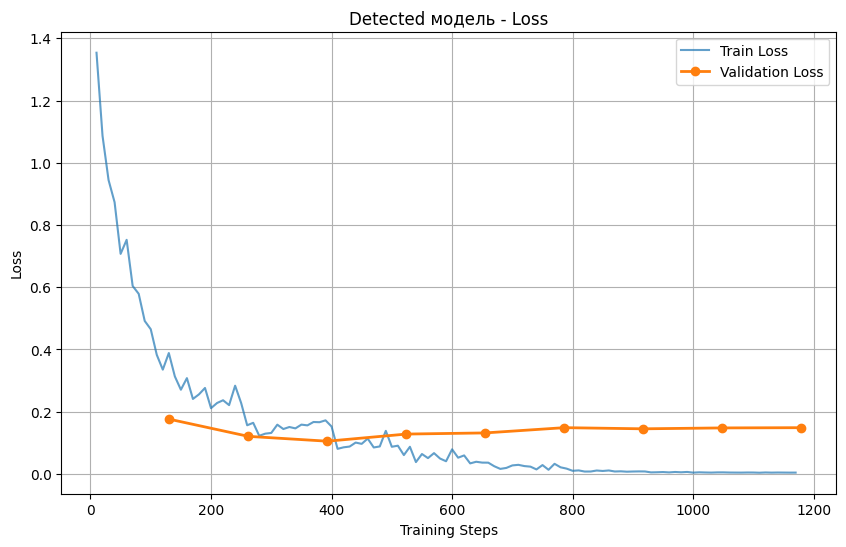

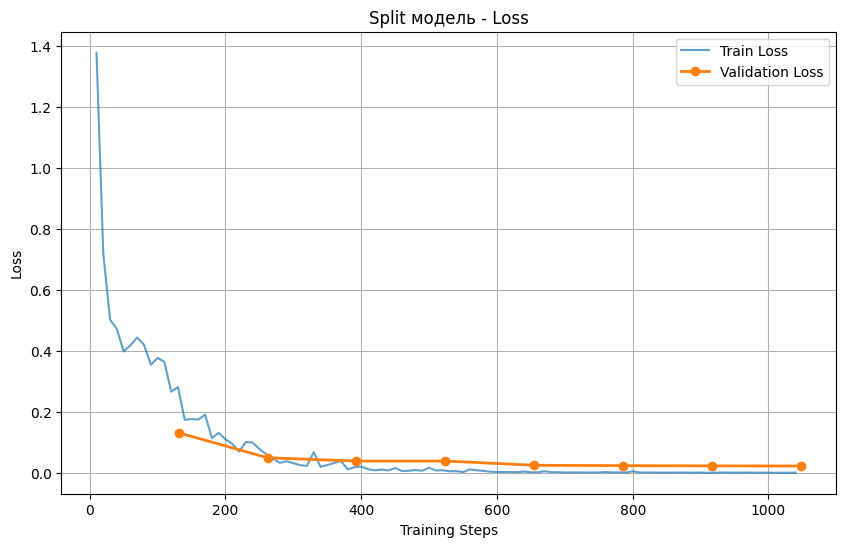

In [8]:
def plot_loss(trainer, title):
    history = trainer.state.log_history
    train_steps = []
    train_losses = []
    eval_steps = []
    eval_losses = []
    epochs_eval = []
    
    for log in history:
        if 'loss' in log and 'step' in log:
            train_steps.append(log['step'])
            train_losses.append(log['loss'])
        if 'eval_loss' in log and 'step' in log:
            eval_steps.append(log['step'])
            eval_losses.append(log['eval_loss'])
            epochs_eval.append(log.get('epoch', len(eval_steps)))
    
    plt.figure(figsize=(10, 6))
    if train_steps:
        plt.plot(train_steps, train_losses, label='Train Loss', alpha=0.7)
    if eval_steps:
        plt.plot(eval_steps, eval_losses, label='Validation Loss', marker='o', linewidth=2)
    plt.xlabel('Training Steps')
    plt.ylabel('Loss')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

print("=== Training & Validation Loss ===")
plot_loss(trainer_detected, "Detected модель - Loss")
plot_loss(trainer_split, "Split модель - Loss")

=== Precision & Recall на валидации ===


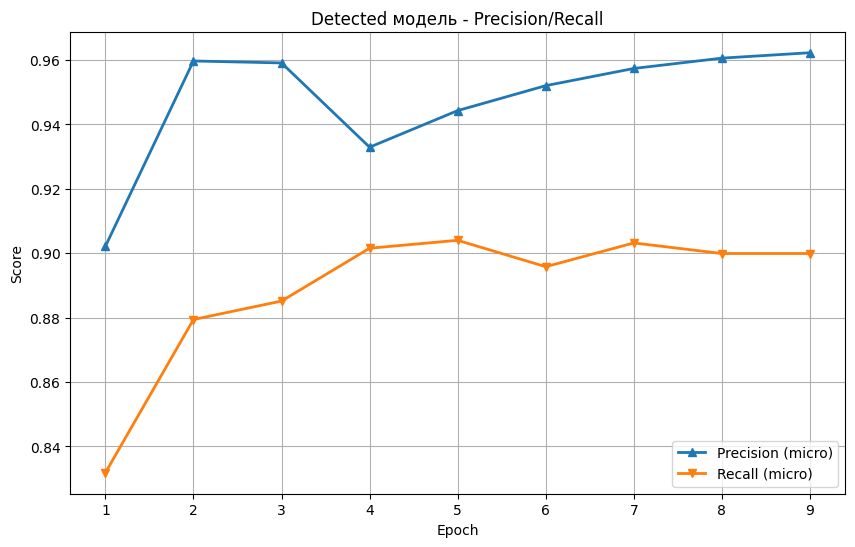

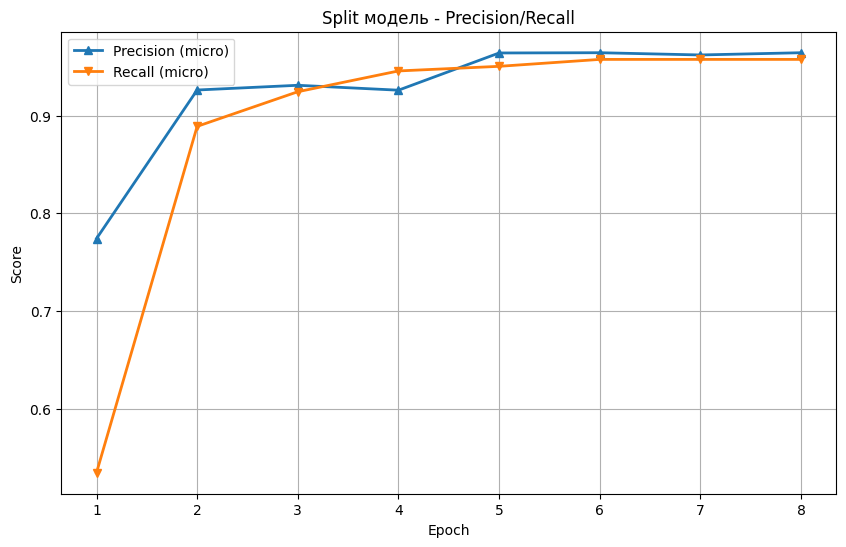

In [10]:
def plot_precision_recall(trainer, title):
    history = trainer.state.log_history
    epochs = []
    precisions = []
    recalls = []
    for log in history:
        if 'eval_micro_precision' in log:
            epochs.append(log.get('epoch'))
            precisions.append(log.get('eval_micro_precision'))
            recalls.append(log.get('eval_micro_recall'))
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, precisions, marker='^', label='Precision (micro)', linewidth=2)
    plt.plot(epochs, recalls, marker='v', label='Recall (micro)', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Score')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

print("=== Precision & Recall на валидации ===")
plot_precision_recall(trainer_detected, "Detected модель - Precision/Recall")
plot_precision_recall(trainer_split, "Split модель - Precision/Recall")

=== Learning Rate Schedule ===


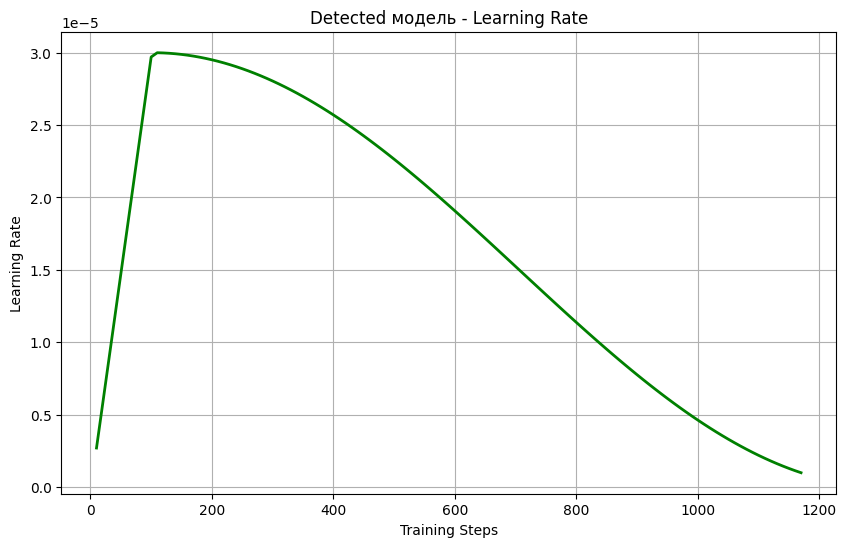

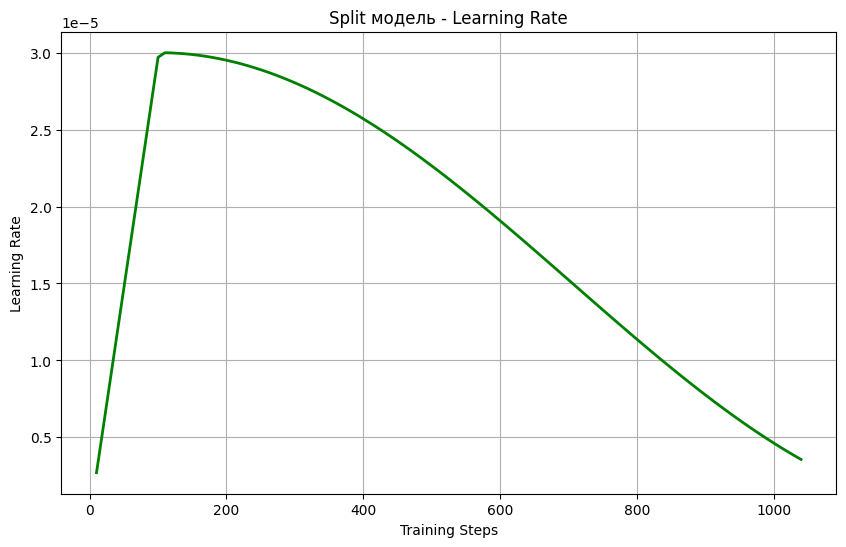

In [11]:
def plot_lr(trainer, title):
    history = trainer.state.log_history
    steps = []
    lrs = []
    for log in history:
        if 'learning_rate' in log and 'step' in log:
            steps.append(log['step'])
            lrs.append(log['learning_rate'])
    plt.figure(figsize=(10, 6))
    plt.plot(steps, lrs, color='green', linewidth=2)
    plt.xlabel('Training Steps')
    plt.ylabel('Learning Rate')
    plt.title(title)
    plt.grid(True)
    plt.show()

print("=== Learning Rate Schedule ===")
plot_lr(trainer_detected, "Detected модель - Learning Rate")
plot_lr(trainer_split, "Split модель - Learning Rate")

Вычисление предсказаний для Detected Model...


  [VAL DEBUG] TP=1097 FP=43 FN=122 | true=1219 pred=1140


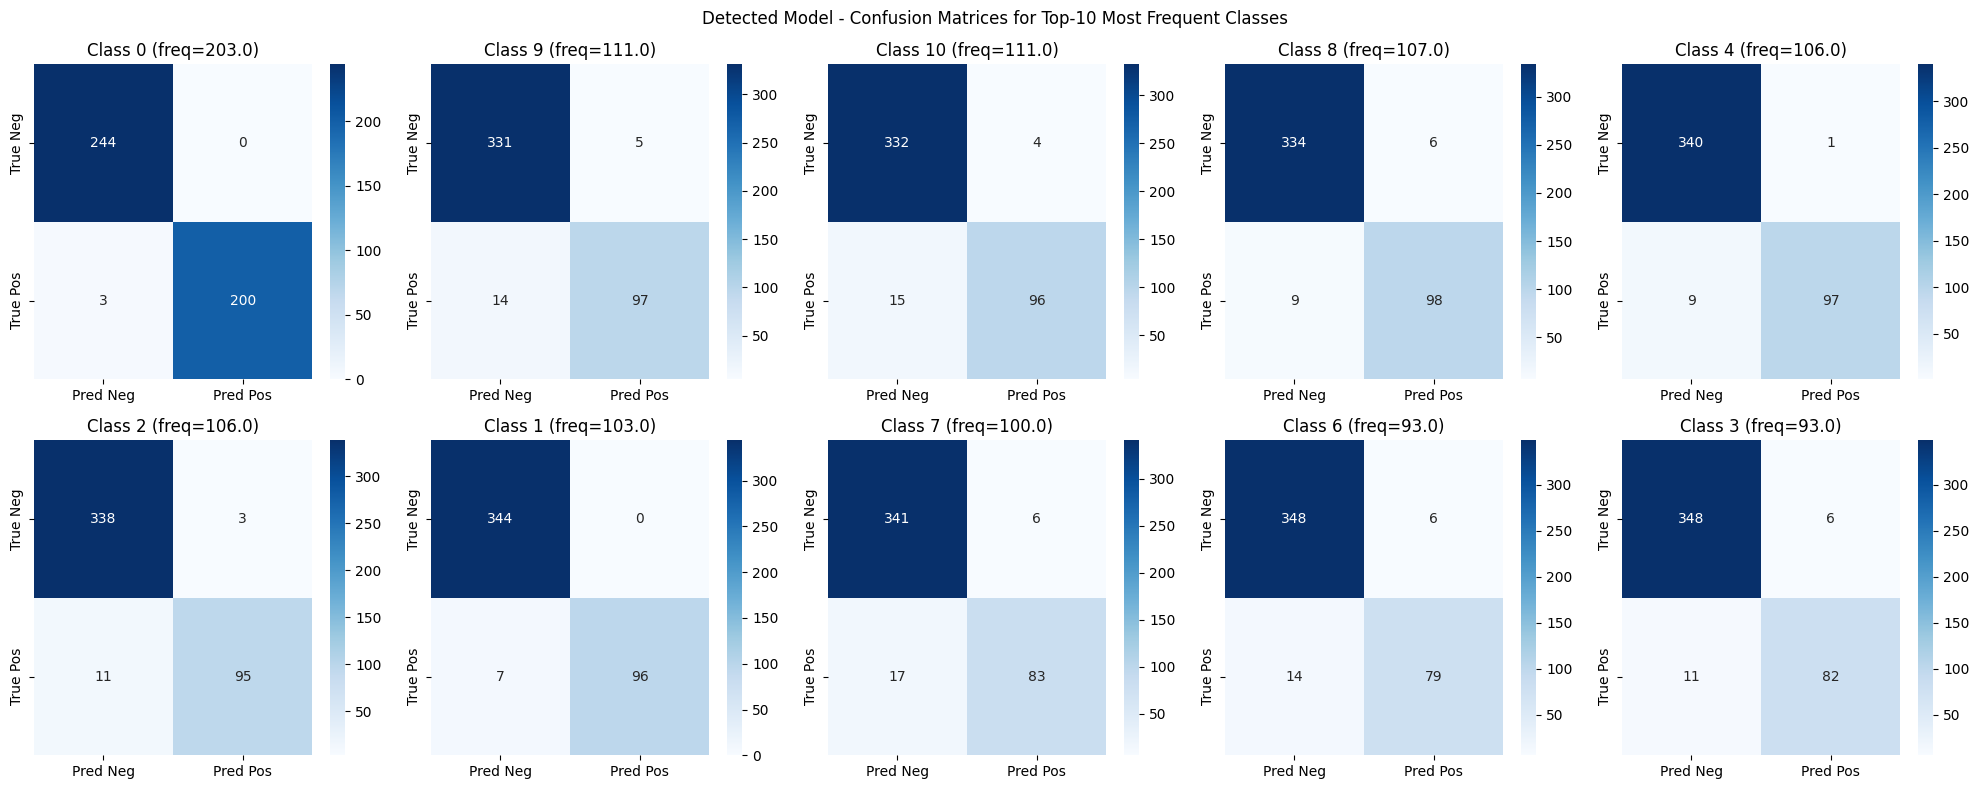

Вычисление предсказаний для Split Model...


  [VAL DEBUG] TP=405 FP=15 FN=18 | true=423 pred=420


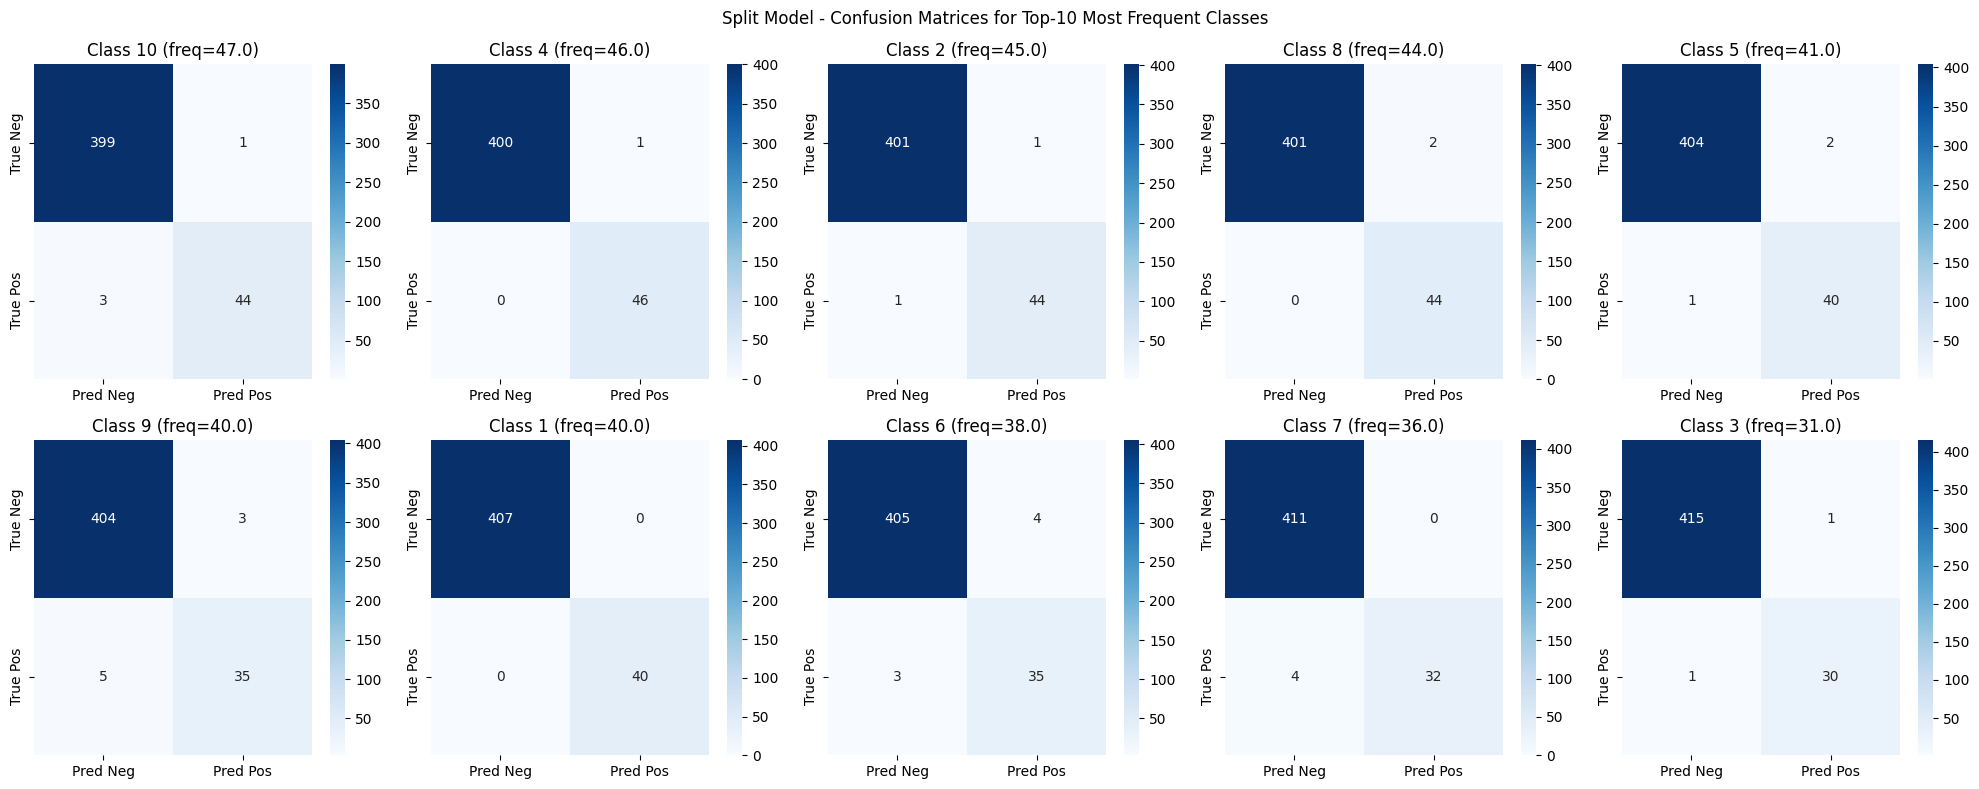

In [12]:
def plot_confusion_matrix(trainer, val_dataset, model_name, top_k=10):
    print(f"Вычисление предсказаний для {model_name}...")
    predictions = trainer.predict(val_dataset)
    logits = predictions.predictions
    true_labels = predictions.label_ids
    pred_labels = (torch.sigmoid(torch.tensor(logits)) > 0.5).numpy().astype(int)
    
    # Частота классов в истинных метках
    class_freq = true_labels.sum(axis=0)
    top_classes = np.argsort(class_freq)[-top_k:][::-1]
    
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    axes = axes.flatten()
    for i, cls in enumerate(top_classes):
        tn, fp, fn, tp = multilabel_confusion_matrix(true_labels, pred_labels)[cls].ravel()
        cm = np.array([[tn, fp], [fn, tp]])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                    xticklabels=['Pred Neg', 'Pred Pos'], yticklabels=['True Neg', 'True Pos'])
        axes[i].set_title(f'Class {cls} (freq={class_freq[cls]})')
    plt.suptitle(f'{model_name} - Confusion Matrices for Top-{top_k} Most Frequent Classes')
    plt.tight_layout()
    plt.show()

# Для Detected модели (используем val_dataset_d)
plot_confusion_matrix(trainer_detected, val_dataset_d, "Detected Model", top_k=10)

# Для Split модели (используем val_dataset_s)
plot_confusion_matrix(trainer_split, val_dataset_s, "Split Model", top_k=10)

In [13]:
def final_metrics(trainer, name):
    history = trainer.state.log_history
    last_eval = None
    for log in reversed(history):
        if 'eval_micro_f1' in log:
            last_eval = log
            break
    if last_eval:
        print(f"{name}: Loss={last_eval['eval_loss']:.4f}, F1={last_eval['eval_micro_f1']:.4f}, "
              f"Precision={last_eval['eval_micro_precision']:.4f}, Recall={last_eval['eval_micro_recall']:.4f}")

print("=== Финальные метрики на валидации ===")
final_metrics(trainer_detected, "Detected")
final_metrics(trainer_split, "Split")

=== Финальные метрики на валидации ===
Detected: Loss=0.1487, F1=0.9301, Precision=0.9623, Recall=0.8999
Split: Loss=0.0236, F1=0.9609, Precision=0.9643, Recall=0.9574
